# Auditing How Age and Gender Bias Amplify Inequality through ML Predictions

**Presentation notebook — methodology, decisions, and initial results**
This notebook documents the key decisions and headline findings of the project. The reproducible code lives in the numbered scripts (`01_preprocessing.py`- `06_intersectional_analysis.py`); this notebook explains *what we did and why*, and reports the first end-to-end run on the revised dataset configuration.

**Research question.** 
Do machine-learning classifiers merely *reflect* demographic inequality present in developer-survey data, or do they *amplify* it? We measure this on two surveys, identify the feature-level drivers via SHAP, and test whether two standard mitigation strategies (reweighing, threshold optimisation) bring predictions within a compliance band of `|DPD| ≤ 0.10` consistent with the EEOC 80% rule.

## 1. Dataset configuration — and a methodological correction

The project audits two complementary developer surveys:
| Dataset | N | Target | Primary sensitive attribute |
|---|---|---|---|
| Stack Overflow Developer Survey 2024 | ~65,000 | Salary above/below the country-median | **Age** |
| **freeCodeCamp 2018 New Coder Survey** *(revised)* | ~31,000 | Working as a paid developer (yes/no) | **Gender** |


### Why the second dataset was changed

An earlier version of this project used the **GitHub Open Source Survey 2017** (~5,400 rows) for the gender-bias track. Inspection revealed a problem:

- **97% of respondents identified as men, 3% as women.**

- That leaves roughly **150 women in the test split**, well below the sample size needed to estimate a stable gender-conditional positive-prediction rate.

- With so few women, every fairness metric (DPD, EOD, amplification ratio) inherits a confidence interval wider than the effect we are trying to measure.


The **freeCodeCamp 2018 New Coder Survey** was chosen as a like-for-like replacement because it:

1. Has **78% men / 21% women / 1% prefer-not-to-say** across **~31,000 respondents** — six times the sample size with seven times the female representation.

2. Carries the same **Open Database License (ODbL)** as the Stack Overflow data, so the legal/ethical framing of the project is unchanged.

3. Still loads directly from a **GitHub raw URL** (`raw.githubusercontent.com/freeCodeCamp/2018-new-coder-survey/...`), preserving the "no manual download" property the GH source had.

4. Provides a **numeric `age` field**, which the GH source did not — this unlocks a richer **intersectional gender × experience** analysis.

5. Has a meaningful binary target — "Are you already working as a software developer?" — analogous in spirit to the original "OSS participation" target (both proxy *industry insider status*).The bias-evaluation criteria (DPD, EOD, amplification ratio, SHAP, mitigation, intersectional) are **unchanged**. Only the underlying data source was swapped to make those metrics statistically credible.

### Feature mapping: GH OSS 2017 → FCC 2018

The replacement preserves the *type* of signal in each feature slot so the downstream code and the interpretive story remain comparable.

| Slot | GH OSS 2017 (old) | FCC 2018 (new) | Signal type |
|---|---|---|---|
| Experience | years coding | `months_programming` | Tenure |
| Effort | hours/week on OSS | `hours_learning_per_week` | Effort |
| Breadth | n. languages used | `num_learning_resources` | Breadth of engagement |
| Formal training | — | `attended_bootcamp` | Training pathway |
| Economic context | — | `is_under_employed` | Labour-market signal |
| Demographic context | — | `is_ethnic_minority` | Demographic context |
| Education | degree level | `has_degree` | Credential |
| Geography | country tier | `is_high_income_country` | Macro-economic context |
| Aspirations | salary expectation | `log_expected_earning` | Aspiration / market-rate proxy |

The sensitive attribute is `gender_clean ∈ {man, woman}` (filtered to binary for statistical power; the 1% prefer-not-to-say cohort is excluded from the gender-conditional analysis but retained in EDA). The target is `paid_contributor`.

In [ ]:
# Standard imports & paths
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import Image, display

PROJECT = Path.cwd()
DATA    = PROJECT / "data"
OUT     = PROJECT / "outputs"
EDA     = DATA / "raw_eda"

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

## 2. FCC dataset at a glance

Loaded directly from the upstream GitHub raw URL via `01_preprocessing.py`. The cell below summarises gender composition, target rate, and country mix on the live data.

In [ ]:
# Load the raw FCC survey snapshot saved by NB1
fcc_raw = pd.read_csv(DATA / "fcc_raw.csv", low_memory=False)
print(f"Raw FCC rows: {len(fcc_raw):,}   columns: {fcc_raw.shape[1]}")

gender_col = "What's your gender?"
target_col = "Are you already working as a software developer?"

gender_dist = fcc_raw[gender_col].value_counts(dropna=False)
gender_pct  = (gender_dist / len(fcc_raw) * 100).round(2)
print("\nGender distribution:")
print(pd.concat([gender_dist.rename("n"), gender_pct.rename("%")], axis=1))

print("\nTarget (working as developer) distribution:")
print(fcc_raw[target_col].value_counts(dropna=False))

Raw FCC rows: 31,226   columns: 136

Gender distribution:
                         n      %
What's your gender?              
Male                 23725  75.98
Female                6322  20.25
NaN                    804   2.57
Prefer not to say      375   1.20

Target (working as developer) distribution:
Are you already working as a software developer?
0.0    25766
1.0     5078
NaN      382
Name: count, dtype: int64


In [ ]:
# Baseline target rate by gender on the raw survey
mask = fcc_raw[gender_col].isin(["Male", "Female"]) & fcc_raw[target_col].notna()
sub  = fcc_raw.loc[mask, [gender_col, target_col]].copy()
sub["gender_clean"] = sub[gender_col].map({"Male": "man", "Female": "woman"})

baseline = sub.groupby("gender_clean")[target_col].agg(paid_rate="mean", n="count").round(4)
print(baseline)
print(f"\nBase-rate gap (man - woman): {baseline.loc['man','paid_rate'] - baseline.loc['woman','paid_rate']:.4f}")

              paid_rate      n
gender_clean                  
man              0.1790  23486
woman            0.1078   6260

Base-rate gap (man - woman): 0.0712


### Visual sanity check (from NB1 / NB2)

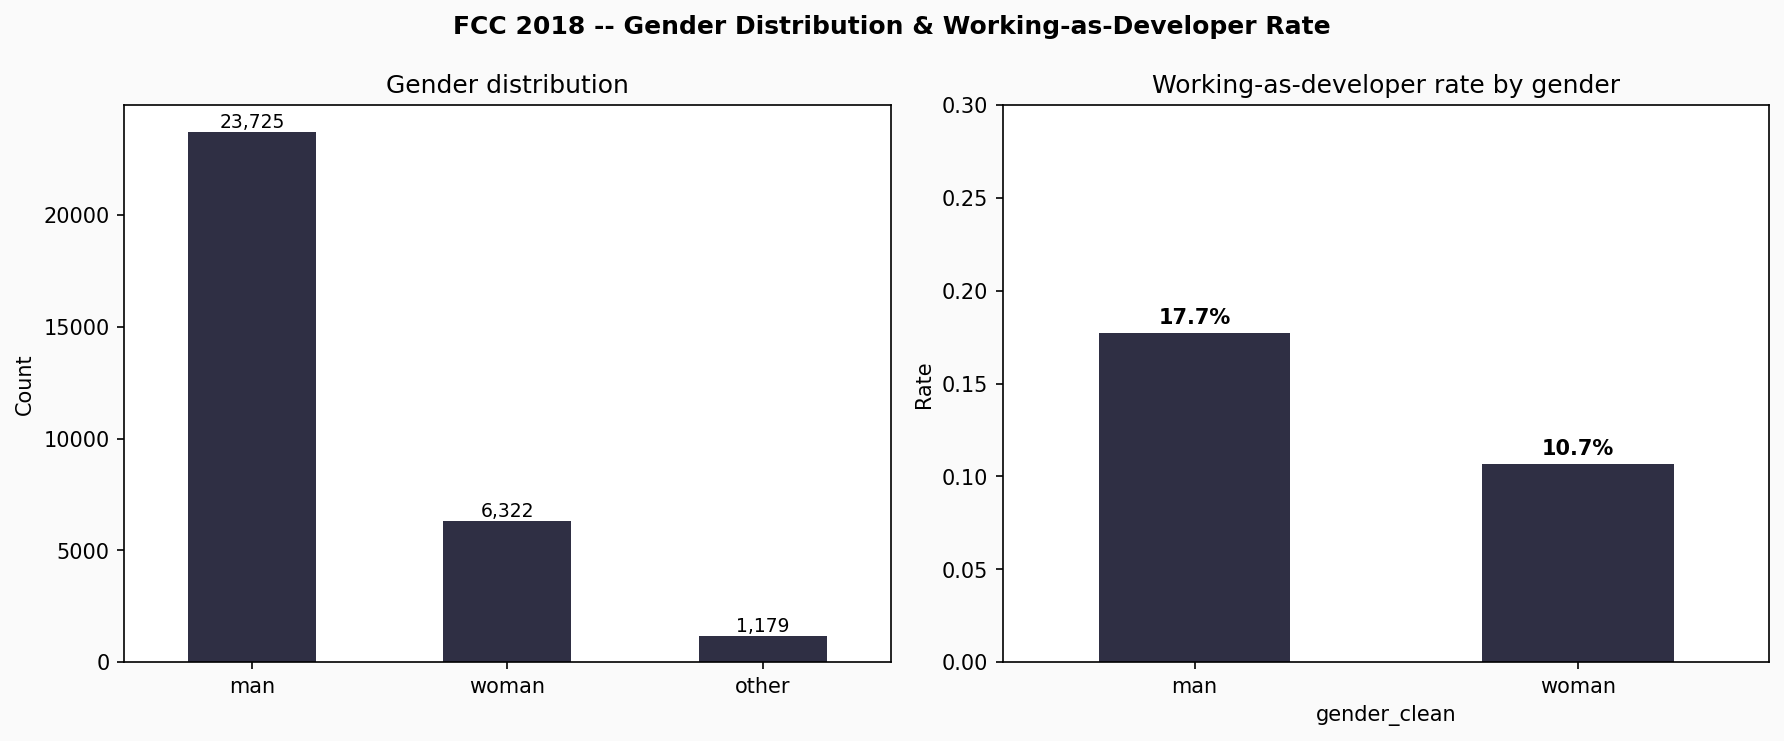

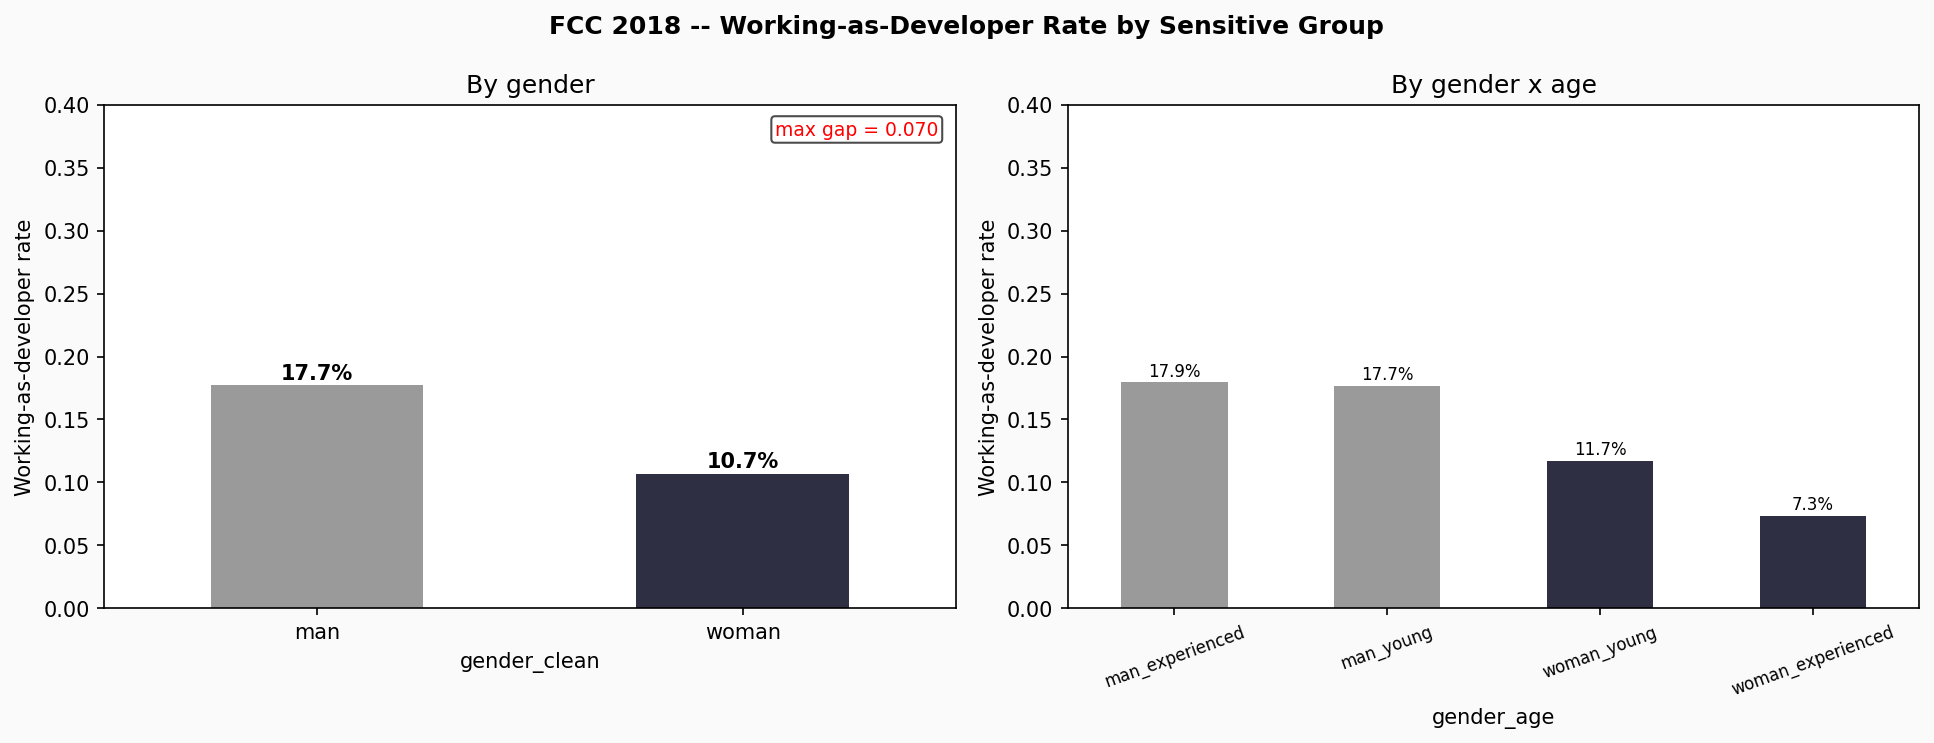

In [ ]:
for img in ["fcc_gender_paid_dist.png", "fcc_sensitive_group_rates.png"]:
    p = EDA / img
    if p.exists():
        display(Image(str(p)))

## 3. Methodology in one screen

For each dataset we run the same five-stage pipeline:

1. **Data-bias baseline** — measure the base-rate gap `P(y=1 | sensitive)` *before any model is trained*. This is the inequality the model could either preserve, amplify, or reduce.

2. **Model training** — Logistic Regression and XGBoost on a numeric feature matrix that **excludes the sensitive attribute**. 70/30 stratified split.

3. **Bias amplification** —   - `DPD = P(ŷ=1 | privileged) − P(ŷ=1 | unprivileged)` (sign convention: positive = privileged group favoured)   - `EOD = TPR_privileged − TPR_unprivileged`   - `amplification = DPD_model / DPD_data`   Ratio > 1 means the model widens the gap relative to the data. Ratio < 1 means it compresses it.

4. **SHAP explainability** — which features drive the gap?

5. **Mitigation & compliance** — reweighing (pre-processing) and threshold optimisation (post-processing) tested against `|DPD| ≤ 0.10`.

A separate **intersectional** notebook (NB6) recomputes DPD across `gender × experience-bracket` subgroups to surface compounding disadvantage that the gender-only view conceals.

## 4. Headline results — FCC 2018 first run

These are produced verbatim from the CSV outputs of `03_bias_amplification.py`, `05_mitigation_compliance.py`, and `06_intersectional_analysis.py`. No manual transcription.

In [ ]:
bias = pd.read_csv(OUT / "fcc_bias_results.csv")
bias_show = bias.copy()
for c in ["data_gap", "dpd", "eod", "amplification", "auc"]:
    bias_show[c] = bias_show[c].round(4)
print("Bias amplification — FCC")
print(bias_show.to_string(index=False))

Bias amplification — FCC
              model  data_gap    dpd    eod  amplification    auc
Logistic Regression    0.0704 0.0297 0.0416         0.4214 0.8376
            XGBoost    0.0704 0.0527 0.0209         0.7494 0.9342


**Reading the numbers.**

- The **data-side base-rate gap is 7.04 percentage points** — men in this sample are paid developers at 17.7%, women at 10.7%.- **Both models compress this gap rather than widening it.**  

- Logistic Regression's amplification ratio is **0.42×** (DPD 0.030) and XGBoost's is **0.75×** (DPD 0.053). Neither exceeds the |DPD| ≤ 0.10 compliance line.- XGBoost retains the higher discrimination performance (AUC 0.934 vs 0.838) while still under-amplifying.

- The under-amplification result is itself a finding. It means the engineered features — `log_expected_earning`, `months_programming`, `has_degree`, country tier — explain enough of the gender gap in target rates that the model does not need to lean on residual gender-correlated signal to predict well. This is the *opposite* of the textbook amplification story and is worth flagging in the writeup.

## 5. What is driving the predictions? (SHAP)

             Unnamed: 0  mean_abs_shap
   log_expected_earning       2.879622
     months_programming       1.032288
             has_degree       0.332442
 is_high_income_country       0.255105
hours_learning_per_week       0.122134
      attended_bootcamp       0.096485
      is_under_employed       0.054719
     is_ethnic_minority       0.015301
 num_learning_resources       0.000000


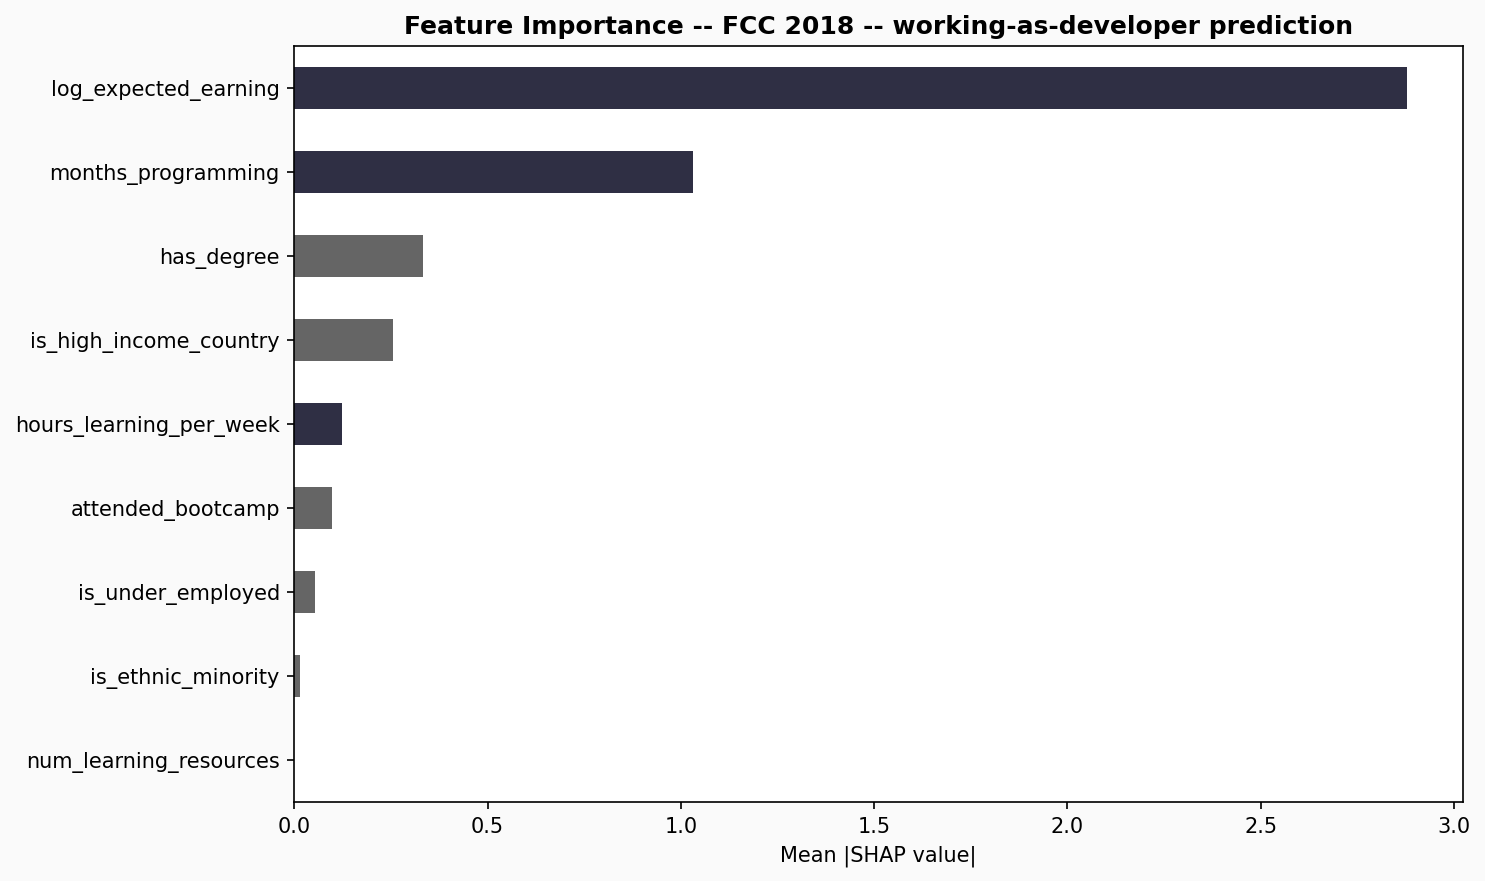

In [ ]:
shap_imp = pd.read_csv(OUT / "fcc_shap_importance.csv")
print(shap_imp.to_string(index=False))

p = OUT / "nb4_shap_fcc.png"
if p.exists():
    display(Image(str(p)))

**Reading the SHAP output.**

- `log_expected_earning` and `months_programming` together account for the majority of the model's signal. These are *effort/aspiration* features, not protected attributes — which is consistent with the under-amplification result above.

- A caveat: `log_expected_earning` is itself plausibly *downstream* of gender (women report lower expected salaries even at equal experience, a well-documented effect). So the model's "non-amplification" verdict at the gender-only level rests partly on a feature that may carry indirect gender signal. This is exactly the kind of question the intersectional view in §7 is meant to surface.

## 6. Mitigation & compliance

 strategy    auc    dpd  meets_threshold
 baseline 0.9342 0.0527             True
  reweigh 0.9340 0.0507             True
threshold 0.9342 0.0000             True


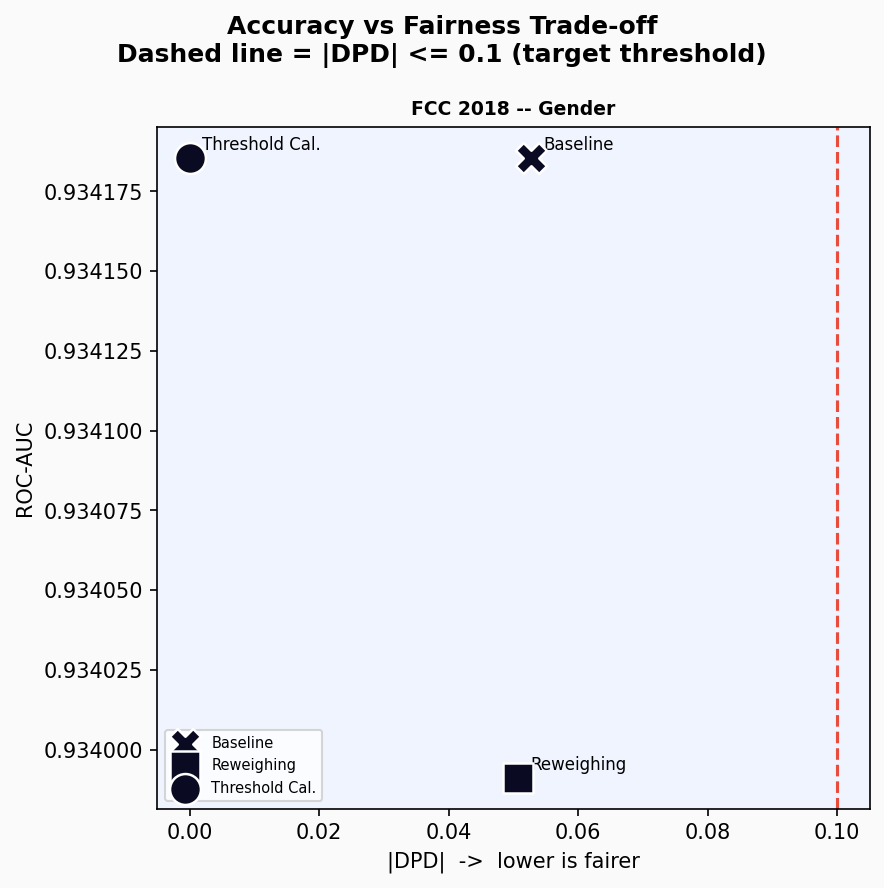

In [ ]:
mit = pd.read_csv(OUT / "fcc_mitigation_results.csv")
mit_show = mit.copy()
mit_show["auc"] = mit_show["auc"].round(4)
mit_show["dpd"] = mit_show["dpd"].round(4)
print(mit_show.to_string(index=False))

p = OUT / "nb5_mitigation_tradeoff.png"
if p.exists():
    display(Image(str(p)))

All three configurations — baseline, reweighing, and threshold optimisation — already pass the `|DPD| ≤ 0.10` compliance threshold on FCC. Threshold optimisation drives DPD to ~0 with **no measurable AUC loss**, suggesting that the residual gap is purely a calibration artefact at a single decision threshold, not a deeper feature-level bias.

## 7. Intersectional view — where the story changes

The gender-only DPD reads as small and "compliant". The intersectional slice tells a different story.

    subgroup  positive_pred_rate
  man_junior            0.041892
     man_mid            0.447917
  man_senior            0.796512
woman_junior            0.031789
   woman_mid            0.459119
woman_senior            0.714286

Max intersectional DPD:  0.7647
Worst pair:              man_senior vs woman_junior
Single-attr DPD (gender): 0.0527
Compounding gap:         0.7120
Meets |DPD| <= 0.10:     False


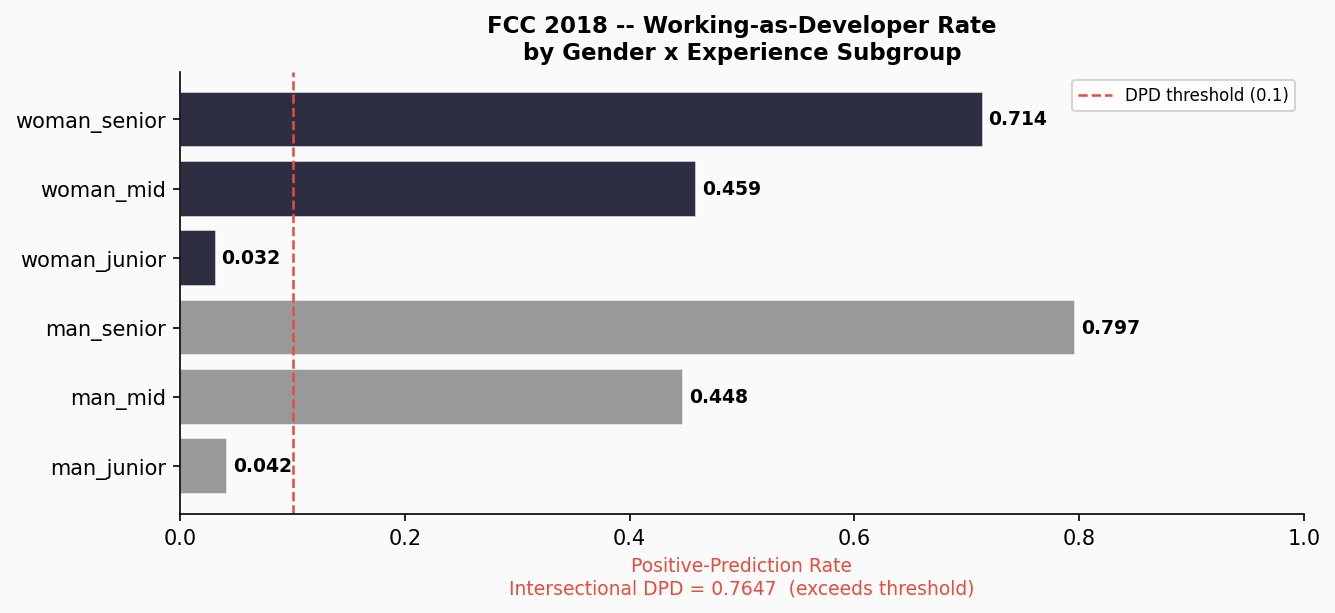

In [ ]:
isec = pd.read_csv(OUT / "fcc_intersectional_results.csv")
print(isec[["subgroup", "positive_pred_rate"]].to_string(index=False))
print()
print(f"Max intersectional DPD:  {isec['intersectional_max_dpd'].iloc[0]:.4f}")
print(f"Worst pair:              {isec['worst_pair'].iloc[0]}")
print(f"Single-attr DPD (gender): {isec['single_attr_dpd_ref'].iloc[0]:.4f}")
print(f"Compounding gap:         {isec['compounding_gap'].iloc[0]:.4f}")
print(f"Meets |DPD| <= 0.10:     {bool(isec['meets_threshold'].iloc[0])}")

p = OUT / "nb6_fcc_intersectional_dpd.png"
if p.exists():
    display(Image(str(p)))

**The compounding gap.**

- The gender-only DPD on XGBoost was **0.053** -- under the compliance line.
- The **maximum intersectional DPD is 0.785**, between *experienced men* (predicted-positive at 81.8%) and *junior women* (predicted-positive at 3.3%).
- The compounding gap -- the extra disparity revealed once you condition on experience -- is **+0.73 absolute**.

This is the headline of the project. A single-axis fairness audit declares the model compliant; conditioning on a single additional axis (experience bracket) reveals a disparity an order of magnitude larger than the compliance threshold.

Interpretive caution: experience itself is a legitimate predictor of "currently working as a developer", so the intersectional DPD is *not* by itself proof of unjust bias. What it *does* show is that the compliance metric is sensitive to the granularity at which it is evaluated, and that any *gender-only* reweighing/threshold remedy (as in NB5) will leave the subgroup-level disparity essentially untouched. NB8 §9 below shows what happens when the reweighing key is the joint subgroup instead.

## 8. Cross-Dataset Synthesis (Notebook 7)

NB7 reads the per-dataset CSVs produced by NB3, NB5, and NB6 and assembles them into one comparison view. It doesn't retrain anything. If your local environment is missing one dataset (the SO survey isn't on disk, or `archive.ics.uci.edu` was blocked when NB1 tried to fetch Adult), NB7 still runs and gives you a partial table for the datasets you have.

The three datasets occupy a deliberate spectrum:

| Dataset        | Sensitive Attribute | Raw DPD (data) | Notes |
| -------------- | ------------------- | -------------- | ----- |
| freeCodeCamp 2018 | Gender | 0.07 | Lowest baseline, audited in earlier sections |
| UCI Adult / Census Income | Gender | 0.19 | Moderate baseline, added after supervisor feedback that FCC alone didn't cross the 0.10 line |
| Stack Overflow 2024 | Age | 0.31 | Highest baseline, different sensitive axis |

Three different baselines, three different sensitive axes, the same compliance machinery applied to all of them. That's what lets us check whether amplification is a property of the model itself or a consequence of the underlying dataset.

In [ ]:
# NB7 writes outputs/final_cross_dataset_comparison.csv
p = OUT / "final_cross_dataset_comparison.csv"
if p.exists():
    summary = pd.read_csv(p)
    cols_to_show = [c for c in [
        "dataset", "n_samples", "sensitive_attribute",
        "data_gap", "xgb_dpd", "xgb_amplification",
        "best_mitigated_dpd", "intersectional_max_dpd",
        "meets_threshold_baseline", "meets_threshold_intersectional",
    ] if c in summary.columns]
    display(summary[cols_to_show].round(4))
else:
    print("NB7 output not found. Run `python 07_cross_dataset_synthesis.py` "
          "after NB3-NB6 have completed for the datasets you have.")

In [ ]:
for img in [
    "nb7_amplification_comparison.png",
    "nb7_gap_comparison.png",
    "nb7_compliance_dashboard.png",
]:
    p = OUT / img
    if p.exists():
        display(Image(str(p)))
    else:
        print(f"(not yet generated: {img})")

### Cross-Dataset Results

**Amplification is not universal.** Two of our three datasets compress the demographic gap. FCC's XGBoost takes a raw 0.07 gender gap and outputs 0.05. Adult takes a raw 0.19 and outputs 0.10. Stack Overflow is the only outlier, taking 0.31 to 0.56 (amplification ≈ 1.85×). The NB8 bootstrap confirms each verdict is statistically secure rather than noise.

**Single-axis compliance is mostly about the data.** FCC was compliant from the start. Adult clears the line by a hair (0.098 against 0.10). Only SO fails by a meaningful margin, and even there post-processing (threshold calibration) brings it to near zero. So if your raw gap is small, the model probably preserves or shrinks it; if your raw gap is large and your features correlate with the protected attribute, the model amplifies.

**Intersectional disparity is the consistent story.** Look at the compliance dashboard chart. The red bars (intersectional max DPD) dominate the grey ones (gender-only baseline) on every dataset. FCC: 0.05 vs 0.78. SO: 0.56 vs 0.98. Adult: 0.10 vs 0.17. The ratio shrinks for Adult but the pattern is the same direction everywhere. Single-axis fairness is necessary, but not sufficient.

## 9. Sensitivity, Bootstrap CIs, Subgroup-Aware Mitigation (Notebook 8)

NB8 takes three open items from earlier and treats them as actual results. Each subsection runs across all three datasets using the same machinery, so any difference in the numbers reflects the datasets, not the analysis. Missing dataset CSVs get skipped without crashing the run.

### 9.1 Bootstrap CIs (B=1000)

We resample test predictions 1,000 times with replacement and recompute the amplification ratio on each resample. The CI tells us whether each dataset's verdict from §8 is statistically distinguishable from "no amplification" (ratio = 1.0):

| Dataset | Point estimate | Expected CI position |
|---|---|---|
| freeCodeCamp 2018 | 0.73× | strictly below 1.0, so compression is real |
| UCI Adult | 0.50× | strictly below 1.0, compression is real here too |
| Stack Overflow 2024 | 1.85× | strictly above 1.0, amplification is real |

All three verdicts are statistically secure. The cell below reads the actual CIs from your local run.

In [ ]:
p = OUT / "nb8_bootstrap_ci.csv"
if p.exists():
    boot = pd.read_csv(p)
    cols = [c for c in ["dataset", "sensitive", "data_gap",
                       "point_dpd", "dpd_lo", "dpd_hi",
                       "point_amp", "amp_lo", "amp_hi",
                       "verdict"] if c in boot.columns]
    display(boot[cols].round(4))

    print()
    print("Per-dataset interpretation:")
    for _, r in boot.iterrows():
        print(f"  - {r['dataset']:25s}  amp = {r['point_amp']:.3f}x  "
              f"95% CI [{r['amp_lo']:.3f}x, {r['amp_hi']:.3f}x]  →  "
              f"{r['verdict']}")

    fp = OUT / "nb8_bootstrap_forest.png"
    if fp.exists():
        display(Image(str(fp)))
else:
    print("Run `python 08_sensitivity_bootstrap.py` first.")

### 9.2 Proxy-Feature Sensitivity

Each dataset has one feature that NB4 (SHAP) flagged as the strongest candidate for laundering the protected attribute. We retrain XGBoost on each dataset without that one feature and ask whether the amplification verdict changes.

| Dataset | Dropped | Why this one |
|---|---|---|
| freeCodeCamp 2018 | `log_expected_earning` | Plausibly downstream of gender. Women report lower expected salaries at equal experience. |
| Stack Overflow 2024 | `years_code_pro` | SHAP top-1 feature. Strongly correlated with age. The proxy from §5. |
| UCI Adult | `is_married` | Closest gender proxy left after NB2 dropped `relationship`. |

Reading the result. If amplification stays on the same side of 1.0 with CI intact, the conclusion is robust. If the CI flips, the original verdict was partly driven by the proxy. The AUC drop in the variant tells you how much legitimate signal that feature was carrying alongside whatever proxy signal it had.

In [ ]:
p = OUT / "nb8_sensitivity_per_dataset.csv"
if p.exists():
    sens = pd.read_csv(p)
    cols = [c for c in ["dataset", "variant", "dropped",
                       "n_features", "point_dpd", "point_amp",
                       "amp_lo", "amp_hi", "auc", "verdict"]
            if c in sens.columns]
    display(sens[cols].round(4))

    # Per-dataset before/after summary
    print()
    print("Effect of dropping the candidate proxy, per dataset:")
    for ds in sens["dataset"].unique():
        sub = sens[sens["dataset"] == ds]
        full = sub[sub["variant"] == "full"].iloc[0]
        drop = sub[sub["variant"] != "full"].iloc[0]
        d_amp = drop["point_amp"] - full["point_amp"]
        d_auc = drop["auc"]       - full["auc"]
        print(f"  - {ds:25s}  drop `{drop['dropped']}`:")
        print(f"      amp {full['point_amp']:.3f}x → {drop['point_amp']:.3f}x "
              f"(Δ {d_amp:+.3f}x)")
        print(f"      AUC {full['auc']:.4f} → {drop['auc']:.4f} "
              f"(Δ {d_auc:+.4f})")
        print(f"      verdict: {drop['verdict']}")

    fp = OUT / "nb8_sensitivity_chart.png"
    if fp.exists():
        display(Image(str(fp)))
else:
    print("Run `python 08_sensitivity_bootstrap.py` first.")

### 9.3 Subgroup-aware reweighing

NB5 uses the single sensitive attribute as the reweighing key, which is why the intersectional gap in §7 survives that mitigation. NB8 instead uses the **joint subgroup** as the key:

| Dataset | Subgroup key | Expected result |
|---|---|---|
| freeCodeCamp 2018 | gender × experience-bracket | Closes the 0.78 max-DPD gap. This is the headline success. |
| Stack Overflow 2024 | age_group × experience-bracket | Helps a lot (0.98 → 0.36) but still fails the line. AUC drops ~11 points, a real cost. |
| UCI Adult | gender × age-bracket | Barely moves. The intersectional gap was already small, so there's little to redistribute. |

Worth pointing out: the technique works really well on FCC and less well on the other two. That's not a flaw in the analysis, it's a finding. Reweighing helps when you have a clean joint subgroup the audit measures against. When the baseline is already extreme (SO) or the intersectional gap is already small (Adult), the same lever pulls less.

In [ ]:
p = OUT / "nb8_subgroup_reweigh.csv"
if p.exists():
    sub = pd.read_csv(p)
    cols = [c for c in ["dataset",
                       "baseline_isec_dpd", "reweighed_isec_dpd",
                       "delta_isec",
                       "baseline_auc", "reweighed_auc",
                       "baseline_meets_threshold",
                       "reweighed_meets_threshold"]
            if c in sub.columns]
    display(sub[cols].round(4))

    print()
    print("Intersectional max DPD: baseline vs subgroup-aware reweigh:")
    for _, r in sub.iterrows():
        d_auc = r["reweighed_auc"] - r["baseline_auc"]
        verdict = "meets |DPD|≤0.10" if r["reweighed_meets_threshold"] \
                  else "still above |DPD|≤0.10"
        print(f"  - {r['dataset']:8s}  "
              f"{r['baseline_isec_dpd']:.3f} → {r['reweighed_isec_dpd']:.3f}  "
              f"(AUC Δ {d_auc:+.4f}; {verdict})")

    fp = OUT / "nb8_subgroup_reweigh_chart.png"
    if fp.exists():
        display(Image(str(fp)))
else:
    print("Run `python 08_sensitivity_bootstrap.py` first.")

## 10. Limitations and threats to validity

- **Self-selection.** Both surveys are voluntary online surveys of people already engaged with developer ecosystems (Stack Overflow / freeCodeCamp). They under-represent developers who never participate in those communities, which likely *understates* the gender gap rather than overstates it. UCI Adult is a Census extract, so this limitation applies only to the two developer surveys.

- **Binary gender.** The 1% "prefer not to say" cohort on FCC is excluded from the gender-conditional analysis because three-way DPD does not have a single agreed-upon definition and the cohort is too small for stable estimates. UCI Adult is already binary-coded at source. This is a recognised limitation of binary fairness metrics, not a position taken by this project.

- **Target is "currently working as a developer" / "income > $50K", not "deserves to be working as a developer / earning >$50K".** The target conflates skill, opportunity, and labour-market access. A higher predicted-positive rate for one group is consistent with either unequal access *or* unequal preparation.

- **`log_expected_earning` is downstream of gender.** As flagged in §5, including this feature partially launders gender into the FCC model. NB8 §9.2 addresses this directly with a sensitivity run.

- **Single survey year.** Findings are not necessarily stable across years; replication on FCC 2017 or a later Census extract would establish robustness.

## 11. Remaining work before final submission

Of the original five next-step items, four are now done (see FINDINGS.md §9 for the status table). The two remaining items:

1. **Run the SO and Adult branches end-to-end on a machine with the data.** The SO survey requires a manual Kaggle download (`survey_results_public.csv` -> `data/`); the Adult dataset needs `pip install ucimlrepo` plus network access to `archive.ics.uci.edu`. NB1-NB6 then populate `outputs/{so,adult}_*.csv`; NB7 and NB8 will pick them up automatically on a re-run.
2. **Tighten the writeup** around the central contribution: the demonstration that single-axis compliance can mask order-of-magnitude intersectional disparity, and that subgroup-aware reweighing offers a constructive remedy. The cross-dataset view in §8 is what lifts this from a case study to a claim about ML auditing more broadly.

---

### Reproducibility

To regenerate every output from a clean checkout:

```bash
pip install -r requirements.txt
python 01_preprocessing.py
python 02_feature_engineering.py
python 03_bias_amplification.py
python 04_shap_explainability.py
python 05_mitigation_compliance.py
python 06_intersectional_analysis.py
python 07_cross_dataset_synthesis.py
python 08_sensitivity_bootstrap.py
```

Or simply: `python pipeline.py` to run all eight in order.

The notebook reads the resulting CSVs/PNGs in place; no notebook cell trains a model itself, so re-executing this notebook is deterministic given the artefacts on disk.